In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

# 1. Create a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# 3. Get probability estimates
y_probs = model.predict_proba(X_test)[:, 1]

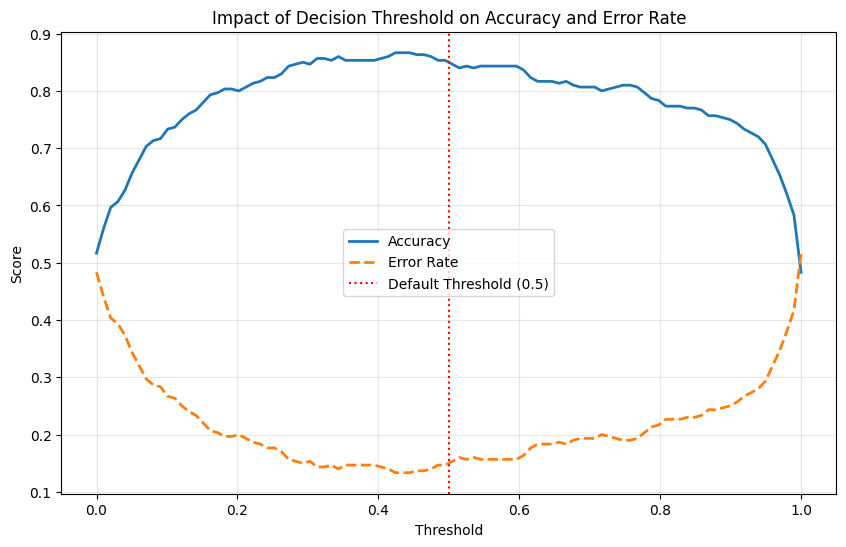

In [6]:
# 4. Analyze different thresholds
thresholds = np.linspace(0, 1, 100)
metrics = []

for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    metrics.append({
        'threshold': t,
        'accuracy': accuracy_score(y_test, y_pred),
        'error_rate': 1 - accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics)

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.plot(metrics_df['threshold'], metrics_df['accuracy'], label='Accuracy', lw=2)
plt.plot(metrics_df['threshold'], metrics_df['error_rate'], label='Error Rate', lw=2, linestyle='--')
plt.axvline(0.5, color='red', linestyle=':', label='Default Threshold (0.5)')
plt.title('Impact of Decision Threshold on Accuracy and Error Rate')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()